<a href="https://colab.research.google.com/github/tgrappoport/pythoncamp/blob/main/Aula1_Modelo_TB_cont.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

np.set_printoptions(precision=4, suppress=True)

## 8. Grafeno: tight-binding NN na rede honeycomb (cones de Dirac)

O grafeno é um exemplo paradigmático de banda em 2D onde a **geometria** e a **sub-rede**
(A/B) determinam a forma da dispersão.

A rede honeycomb não é uma rede de Bravais: ela pode ser vista como uma rede triangular
(Bravais) com **dois sítios por célula unitária** (sub-redes $A$ e $B$). Isso implica que,
mesmo no modelo mais simples (um orbital por sítio, apenas vizinhos mais próximos),
o Hamiltoniano em $\mathbf{k}$ é uma matriz $2\times 2$.

### 8.1 Hamiltoniano tight-binding NN

Assumindo:
- um orbital por sítio ($p_z$ efetivo),
- hopping apenas entre primeiros vizinhos com amplitude $t$,
- energias onsite iguais (sem termo de massa),

o Hamiltoniano em $\mathbf{k}$ pode ser escrito como

$$
H(\mathbf{k})=
\begin{pmatrix}
0 & f(\mathbf{k}) \\
f^*(\mathbf{k}) & 0
\end{pmatrix},
\qquad
f(\mathbf{k}) = -t\sum_{j=1}^{3} e^{i\mathbf{k}\cdot\boldsymbol{\delta}_j},
$$

onde $\boldsymbol{\delta}_j$ são os três vetores que conectam um sítio $A$ aos seus três
vizinhos $B$.

As bandas são simplesmente

$$
E_\pm(\mathbf{k}) = \pm |f(\mathbf{k})|.
$$

Os pontos onde $f(\mathbf{k})=0$ são os pontos $K$ e $K'$, onde as bandas se tocam e a dispersão
é aproximadamente linear (cones de Dirac).

### Visualização 3D: superfícies $E_+(k_x,k_y)$ e $E_-(k_x,k_y)$

Antes de olhar cortes 1D (caminhos $\Gamma\to K\to M\to\Gamma$), é útil visualizar as bandas
como superfícies sobre o plano $(k_x,k_y)$.

No modelo NN do grafeno:
$$
E_\pm(\mathbf{k})=\pm |f(\mathbf{k})|.
$$

Os cones de Dirac aparecem nos pontos onde $f(\mathbf{k})=0$ (pontos $K$ e $K'$), isto é,
onde as duas superfícies se tocam.

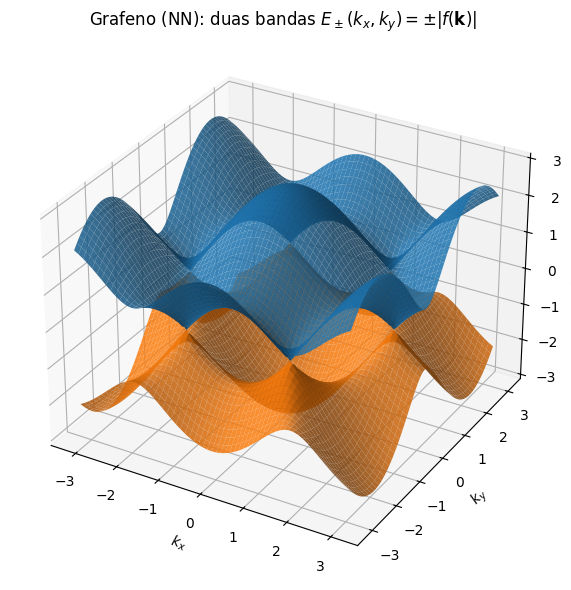

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessário em alguns ambientes

# --- parâmetros ---
a = 1.0
t = -1.0

# Vetores NN A->B (escolha consistente)
delta = np.array([
    [0.0,  a],
    [ np.sqrt(3)/2*a, -0.5*a],
    [-np.sqrt(3)/2*a, -0.5*a]
])

def f_graphene_grid(KX, KY, t=-1.0):
    """f(k) = -t * sum_j exp(i k·delta_j). Funciona diretamente em grids (KX,KY)."""
    f = np.zeros_like(KX, dtype=complex)
    for dx, dy in delta:
        f += np.exp(1j*(KX*dx + KY*dy))
    return -t*f

# --- grade em k ---
Nk = 121
kx = np.linspace(-np.pi/a, np.pi/a, Nk)
ky = np.linspace(-np.pi/a, np.pi/a, Nk)
KX, KY = np.meshgrid(kx, ky, indexing="xy")

Eabs = np.abs(f_graphene_grid(KX, KY, t=t))
Eplus = Eabs
Eminus = -Eabs

# --- plot 3D das DUAS bandas ---
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(KX, KY, Eplus, rstride=2, cstride=2, linewidth=0,
                antialiased=True, alpha=0.85, color="tab:blue")
ax.plot_surface(KX, KY, Eminus, rstride=2, cstride=2, linewidth=0,
                antialiased=True, alpha=0.85, color="tab:orange")

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_zlabel(r"$E(k_x,k_y)$")
ax.set_title(r"Grafeno (NN): duas bandas $E_\pm(k_x,k_y)=\pm|f(\mathbf{k})|$")

plt.tight_layout()
plt.show()

> No grafeno, a presença de duas sub-redes gera um Hamiltoniano $2\times 2$ com uma estrutura
> fora-da-diagonal $f(\mathbf{k})$; a condição $f(\mathbf{k})=0$ define os pontos $K/K'$ e produz
> o toque linear das bandas (cones de Dirac).

Centro do zoom (aprox. K): (np.float64(-1.2042771838760875), np.float64(2.094395102393195))    |f| mínimo = 0.007374479841214084


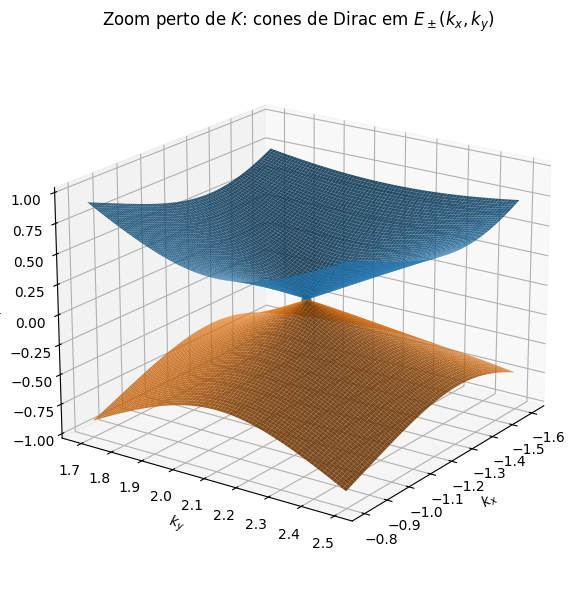

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Reusa: a, t, delta, f_graphene_grid, e a grade KX, KY do bloco anterior.
# Se você já executou o bloco anterior, basta rodar daqui pra baixo.

# (1) encontra automaticamente um "K" (mínimo de |f| na malha)
Eabs = np.abs(f_graphene_grid(KX, KY, t=t))
j0, i0 = np.unravel_index(np.argmin(Eabs), Eabs.shape)  # atenção: (linha, coluna)
Kx0, Ky0 = KX[j0, i0], KY[j0, i0]

print("Centro do zoom (aprox. K):", (Kx0, Ky0), "   |f| mínimo =", Eabs[j0, i0])

# (2) define janela de zoom
dk = 0.4     # ajuste: menor = mais zoom (ex.: 0.25); maior = mais contexto (ex.: 1.0)
Nkz = 161

kx_z = np.linspace(Kx0 - dk, Kx0 + dk, Nkz)
ky_z = np.linspace(Ky0 - dk, Ky0 + dk, Nkz)
KXz, KYz = np.meshgrid(kx_z, ky_z, indexing="xy")

Eabs_z = np.abs(f_graphene_grid(KXz, KYz, t=t))
Eplus_z = Eabs_z
Eminus_z = -Eabs_z

# (3) plota as duas bandas no zoom
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(KXz, KYz, Eplus_z, rstride=2, cstride=2, linewidth=0,
                antialiased=True, alpha=0.9, color="tab:blue")
ax.plot_surface(KXz, KYz, Eminus_z, rstride=2, cstride=2, linewidth=0,
                antialiased=True, alpha=0.9, color="tab:orange")

ax.scatter([Kx0], [Ky0], [0], s=40)  # marca o vértice (aprox.)
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_zlabel(r"$E$")
ax.set_title(r"Zoom perto de $K$: cones de Dirac em $E_\pm(k_x,k_y)$")
ax.view_init(elev=20, azim=35)
plt.tight_layout()
plt.show()

Agora vamos ver onde estão localizados os pontos de simetria:

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-210/1032126852.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.title("Grafeno (NN): mapa de $E_+(\mathbf{k})=|f(\mathbf{k})|$")


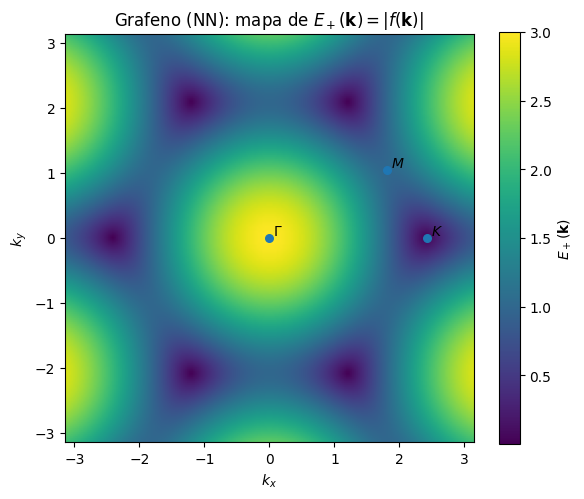

In [2]:
# Mapa em uma região retangular que contém Γ, K, M
Nk = 201
kx = np.linspace(-np.pi/a, np.pi/a, Nk)
ky = np.linspace(-np.pi/a, np.pi/a, Nk)
KX, KY = np.meshgrid(kx, ky, indexing="xy")

Eplus = np.zeros_like(KX)
for i in range(Nk):
    for j in range(Nk):
        Eplus[j, i] = np.abs(f_graphene(KX[j,i], KY[j,i], t=t))  # |f| = E+

plt.figure(figsize=(6,5))
plt.imshow(Eplus, origin="lower",
           extent=[kx[0], kx[-1], ky[0], ky[-1]],
           aspect="equal")
plt.colorbar(label=r"$E_+(\mathbf{k})$")
plt.scatter([G[0], K[0], M[0]], [G[1], K[1], M[1]], s=30)
plt.text(G[0], G[1], r" $\Gamma$", va="bottom")
plt.text(K[0], K[1], r" $K$", va="bottom")
plt.text(M[0], M[1], r" $M$", va="bottom")
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Grafeno (NN): mapa de $E_+(\mathbf{k})=|f(\mathbf{k})|$")
plt.tight_layout()
plt.show()

E finalmente o plot 2D da energia em função do momento por caminhos na zona de Brillouin:

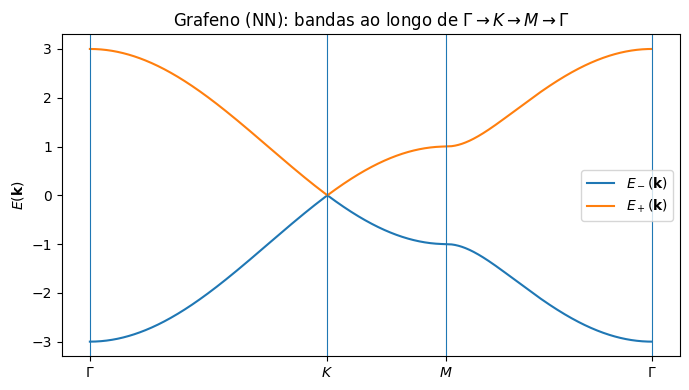

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

# Parâmetros
a = 1.0   # distância NN (unidades)
t = -1.0  # hopping NN (convenção comum)

# Vetores NN do honeycomb: A -> B (escolha consistente)
delta = np.array([
    [0.0,  a],
    [ np.sqrt(3)/2*a, -0.5*a],
    [-np.sqrt(3)/2*a, -0.5*a]
])

def f_graphene(kx, ky, t=-1.0):
    k = np.array([kx, ky])
    phase = np.exp(1j * (delta @ k))   # e^{i k·δ_j}
    return -t * np.sum(phase)

def Hk_graphene(kx, ky, t=-1.0):
    f = f_graphene(kx, ky, t=t)
    return np.array([[0.0, f],
                     [np.conj(f), 0.0]], dtype=complex)

def bands_graphene(kx, ky, t=-1.0):
    # para este caso, E = ±|f|, mas vamos diagonalizar para manter o padrão
    evals = LA.eigvalsh(Hk_graphene(kx, ky, t=t))  # Hermitiano
    return np.sort(evals)

# Vetores primitivos (Bravais triangular) usados para definir b1,b2 e pontos de simetria.
# Para delta acima, uma escolha compatível é:
a1 = np.array([ np.sqrt(3)*a, 0.0])
a2 = np.array([ np.sqrt(3)/2*a, 3/2*a])

# Rede recíproca: b_i tal que a_i · b_j = 2π δ_ij
A = np.column_stack([a1, a2])              # matriz 2x2 com colunas a1,a2
B = 2*np.pi * np.linalg.inv(A).T           # colunas são b1,b2
b1, b2 = B[:,0], B[:,1]

# Pontos de alta simetria (uma convenção comum para honeycomb/triangular)
G = np.array([0.0, 0.0])
M = 0.5*(b1 + b2)
K = (2*b1 + b2)/3.0   # um dos K

def kpath(points, n_per_segment=250):
    k_list = []
    s_list = []
    ticks = [0.0]
    s_acc = 0.0
    for p0, p1 in zip(points[:-1], points[1:]):
        seg = np.linspace(0, 1, n_per_segment, endpoint=False)
        ks = (1-seg)[:,None]*p0 + seg[:,None]*p1
        dk = np.linalg.norm(p1 - p0)
        s_seg = s_acc + seg*dk
        k_list.append(ks)
        s_list.append(s_seg)
        s_acc += dk
        ticks.append(s_acc)
    k_list.append(points[-1][None, :])
    s_list.append(np.array([s_acc]))
    return np.vstack(k_list), np.concatenate(s_list), ticks

# Caminho Γ-K-M-Γ
points = [G, K, M, G]
k_list, s, ticks = kpath(points, n_per_segment=300)

# Calcula bandas
E1 = np.zeros(len(s))
E2 = np.zeros(len(s))
for i, (kx, ky) in enumerate(k_list):
    evals = bands_graphene(kx, ky, t=t)
    E1[i], E2[i] = evals[0], evals[1]

# Plot
plt.figure(figsize=(7,4))
plt.plot(s, E1, label=r"$E_-(\mathbf{k})$")
plt.plot(s, E2, label=r"$E_+(\mathbf{k})$")
plt.xticks(ticks, [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$"])
for tp in ticks:
    plt.axvline(tp, linewidth=0.8)
plt.ylabel(r"$E(\mathbf{k})$")
plt.title("Grafeno (NN): bandas ao longo de $\\Gamma\\to K\\to M\\to \\Gamma$")
plt.legend()
plt.tight_layout()
plt.show()

### Simetrias: reversão temporal (TRS) e inversão (P)

Aqui vamos acompanhar duas simetrias fundamentais em modelos tight-binding:

- **Reversão temporal (TRS)**: em sistemas *sem spin* (spinless), TRS atua como conjugação complexa.
- **Inversão (P)**: troca $\mathbf{r}\to -\mathbf{r}$ e, em redes com duas sub-redes, também pode trocar $A\leftrightarrow B$.

Essas simetrias impõem relações simples para o Hamiltoniano em espaço recíproco $H(k)$.

---

#### TRS (spinless)

Para um sistema sem spin, a condição de TRS pode ser escrita como

$$
\boxed{H(k) = H^*(-k).}
$$

Consequência imediata no espectro:

$$
\boxed{E_n(k)=E_n(-k).}
$$

**Como ver numericamente:** calcular as bandas em $k$ e comparar com as bandas em $-k$.

---

#### Inversão (P)

A inversão muda $k\to -k$, mas também pode agir no espaço interno (por exemplo, trocando sub-redes).
Em geral, existe uma matriz unitária $P$ (que representa a ação da inversão na base escolhida) tal que

$$
\boxed{P\,H(k)\,P^{-1} = H(-k).}
$$

- Se a base é $(A,B)$ e a inversão troca as sub-redes, uma escolha típica é
$$
P=\sigma_x,
$$
onde $\sigma_x$ atua no espaço de sub-rede.

**Como ver numericamente:** verificar se $P H(k) P^{-1}$ coincide com $H(-k)$.

---

#### Comentário importante (para quando introduzirmos spin)

Quando incluirmos spin, TRS deixa de ser “apenas conjugação complexa”:
ela envolve uma rotação no espaço de spin (matriz $i\sigma_y$) além de $k\to -k$.
Mesmo assim, a forma operacional continua a mesma: uma relação entre $H(k)$ e $H(-k)$,
com uma transformação unitária apropriada no espaço interno.

A: TRS ✓  Inversão ✓
  max violação TRS (spinless): 0.0
  max violação inversão: 0.0


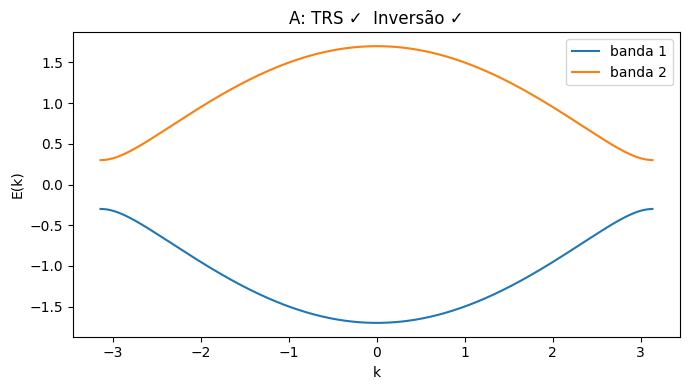

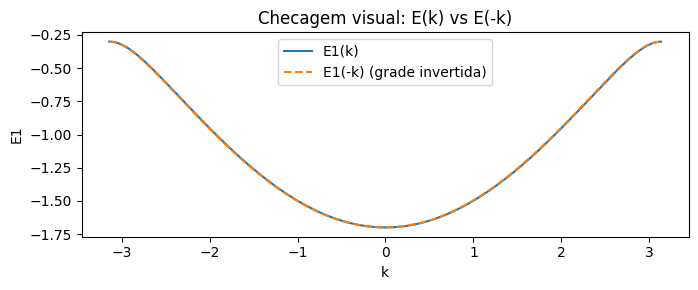

B: TRS ✓  Inversão ✗
  max violação TRS (spinless): 0.0
  max violação inversão: 0.6


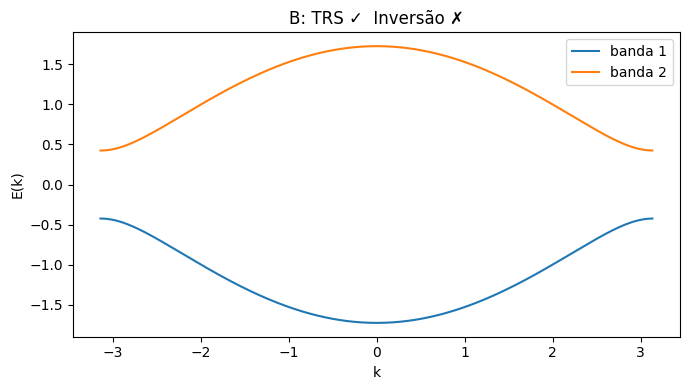

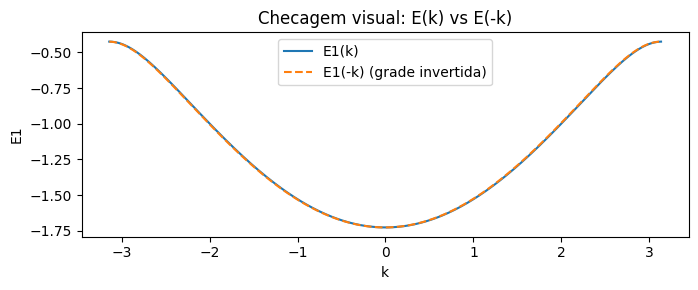

C: TRS ✗  Inversão ✓ (aqui)
  max violação TRS (spinless): 0.5646424733950355
  max violação inversão: 0.5646424733950355


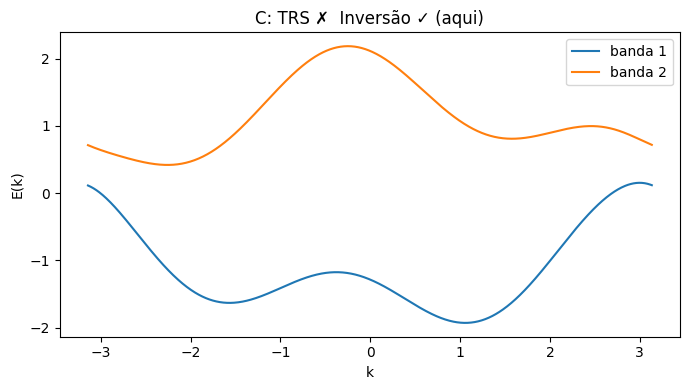

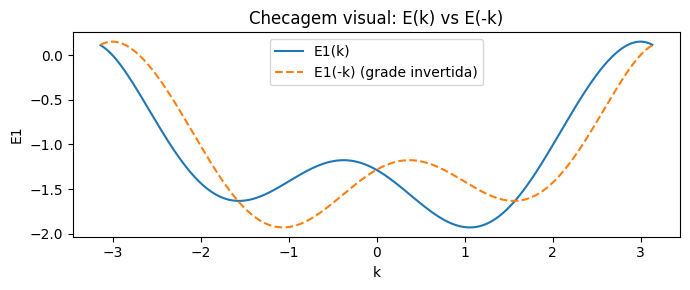

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

a = 1.0

# Operador de inversão na base (A,B): troca sub-redes
sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

def Hk_AB_with_NNN(k, pars):
    """
    Modelo 1D com duas sub-redes A/B por célula:
      - NN tipo SSH: f(k) = t1 + t2 e^{-ika}
      - on-site: epsA, epsB
      - NNN (mesma sub-rede) com fase: 2 tA2 cos(2ka + phiA), 2 tB2 cos(2ka + phiB)

    H(k) =
      [ epsA + 2 tA2 cos(2ka+phiA)      f(k)          ]
      [ f*(k)                        epsB + 2 tB2 cos(2ka+phiB) ]
    """
    t1, t2   = pars["t1"], pars["t2"]
    epsA, epsB = pars["epsA"], pars["epsB"]
    tA2, tB2 = pars["tA2"], pars["tB2"]
    phiA, phiB = pars["phiA"], pars["phiB"]

    f = t1 + t2*np.exp(-1j*k*a)

    dA = epsA + 2.0*tA2*np.cos(2.0*k*a + phiA)
    dB = epsB + 2.0*tB2*np.cos(2.0*k*a + phiB)

    return np.array([[dA, f],
                     [np.conj(f), dB]], dtype=complex)

# --------- Diagnósticos de simetria ---------

def max_TRS_violation(Hk_func, pars, k_grid):
    # TRS spinless: H(k) ?= H^*(-k)
    vals = []
    for ki in k_grid:
        vals.append(np.max(np.abs(Hk_func(ki, pars) - np.conj(Hk_func(-ki, pars)))))
    return np.max(vals)

def max_inversion_violation(Hk_func, pars, k_grid, P=sigma_x):
    # Inversão: P H(k) P^{-1} ?= H(-k)
    Pinv = LA.inv(P)
    vals = []
    for ki in k_grid:
        left = P @ Hk_func(ki, pars) @ Pinv
        right = Hk_func(-ki, pars)
        vals.append(np.max(np.abs(left - right)))
    return np.max(vals)

def bands(Hk_func, pars, k_grid):
    E = np.zeros((2, len(k_grid)))
    for i, ki in enumerate(k_grid):
        E[:, i] = LA.eigvalsh(Hk_func(ki, pars))
    return E

# grade de k simétrica
Nk = 800
k = np.linspace(-np.pi/a, np.pi/a, Nk, endpoint=False)

# --------- Três casos (parâmetros) ---------

# Caso A: TRS OK e inversão OK
pars_A = dict(
    t1=1.0, t2=0.7,
    epsA=0.0, epsB=0.0,          # iguais -> não quebra inversão
    tA2=0.0, tB2=0.0,            # sem NNN -> TRS ok
    phiA=0.0, phiB=0.0
)

# Caso B: TRS OK, inversão quebrada (onsite diferentes)
pars_B = dict(
    t1=1.0, t2=0.7,
    epsA=0.3, epsB=-0.3,         # quebra inversão (com P=sigma_x)
    tA2=0.0, tB2=0.0,
    phiA=0.0, phiB=0.0
)

# Caso C: TRS quebrada com NNN complexo (e aqui deixamos eps iguais para isolar TRS)
pars_C = dict(
    t1=1.0, t2=0.7,
    epsA=0.0, epsB=0.0,
    tA2=0.25, tB2=0.25,          # NNN presente
    phiA=0.6, phiB=0.6           # fase != 0,pi -> quebra TRS
)

cases = [("A: TRS ✓  Inversão ✓", pars_A),
         ("B: TRS ✓  Inversão ✗", pars_B),
         ("C: TRS ✗  Inversão ✓ (aqui)", pars_C)]

for name, pars in cases:
    trs = max_TRS_violation(Hk_AB_with_NNN, pars, k)
    inv = max_inversion_violation(Hk_AB_with_NNN, pars, k, P=sigma_x)
    print(name)
    print("  max violação TRS (spinless):", trs)
    print("  max violação inversão:", inv)

    E = bands(Hk_AB_with_NNN, pars, k)
    plt.figure(figsize=(7,4))
    plt.plot(k, E[0], label="banda 1")
    plt.plot(k, E[1], label="banda 2")
    plt.xlabel("k")
    plt.ylabel("E(k)")
    plt.title(name)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Diagnóstico visual TRS: sobrepor E(k) e E(-k) para a banda 1
    plt.figure(figsize=(7,3))
    plt.plot(k, E[0], label="E1(k)")
    plt.plot(k, E[0][::-1], "--", label="E1(-k) (grade invertida)")
    plt.xlabel("k"); plt.ylabel("E1")
    plt.title("Checagem visual: E(k) vs E(-k)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Exemplo: cadeia 1D monoorbital com hopping de 2º vizinho complexo (quebra de TRS)

Aqui vamos “brincar” com um modelo 1D mínimo onde um **hopping complexo de 2º vizinho**
leva a uma **quebra visível de reversão temporal (TRS)**.

### Hamiltoniano (espaço real)

Consideramos uma cadeia 1D (um orbital por sítio) com:
- energia onsite $\varepsilon$,
- hopping de 1º vizinho real $t_1$,
- hopping de 2º vizinho com fase $\phi$:

$$
H=\sum_R \varepsilon\,|R\rangle\langle R|
+\sum_R \left[t_1\,|R\rangle\langle R+a|+\text{h.c.}\right]
+\sum_R \left[t_2 e^{i\phi}\,|R\rangle\langle R+2a|+\text{h.c.}\right].
$$

### Dispersão $E(k)$

Passando para $k$:

$$
E(k)=\varepsilon + 2t_1\cos(ka) + 2t_2\cos(2ka+\phi).
$$

### Como enxergar a quebra de TRS?

Para um sistema **sem spin**, uma assinatura simples de TRS é a simetria espectral:

$$
E(k)=E(-k).
$$

No modelo acima, se $\phi\neq 0,\pi$, em geral $E(k)\neq E(-k)$ (assimetria em $k$),
o que mostra a quebra de TRS.

phi = 0.000  ->  max |E(k)-E(-k)| = 2.041e-02


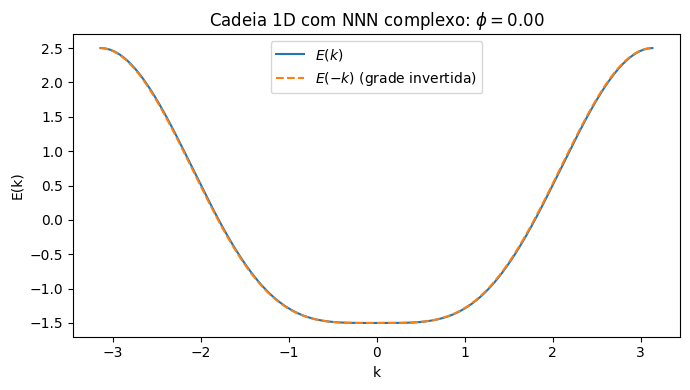

phi = 0.600  ->  max |E(k)-E(-k)| = 5.693e-01


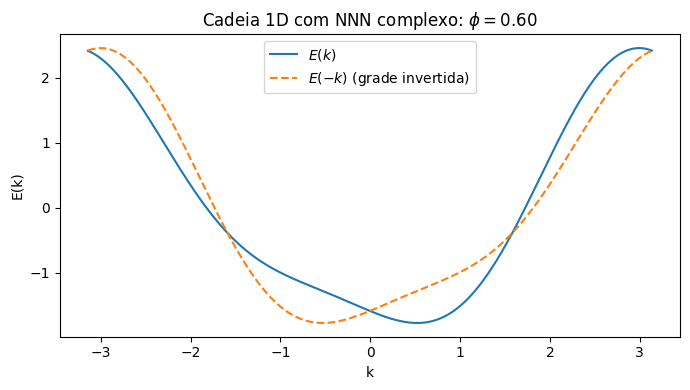

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros
a = 1.0
eps = 0.0
t1 = -1.0
t2 = 0.25

def E_k(k, eps, t1, t2, phi, a=1.0):
    return eps + 2*t1*np.cos(k*a) + 2*t2*np.cos(2*k*a + phi)

Nk = 800
k = np.linspace(-np.pi/a, np.pi/a, Nk, endpoint=False)

# compare dois casos: TRS preservada (phi=0) e TRS quebrada (phi != 0,pi)
phis = [0., 0.6]   # mude 0.6 para pi também e veja TRS voltar

for phi in phis:
    E = E_k(k, eps, t1, t2, phi, a=a)

    # checagem numérica TRS via espectro: E(k) vs E(-k)
    E_minus = E[::-1]  # para grade simétrica, isso corresponde a -k
    print(f"phi = {phi:.3f}  ->  max |E(k)-E(-k)| = {np.max(np.abs(E - E_minus)):.3e}")

    # plot E(k)
    plt.figure(figsize=(7,4))
    plt.plot(k, E, label=r"$E(k)$")
    plt.plot(k, E_minus, "--", label=r"$E(-k)$ (grade invertida)")
    plt.xlabel("k")
    plt.ylabel("E(k)")
    plt.title(fr"Cadeia 1D com NNN complexo: $\phi={phi:.2f}$")
    plt.legend()
    plt.tight_layout()
    plt.show()

## (Extra) Hamiltonianos não-Hermitianos: energias complexas e o que significa

Até aqui trabalhamos com Hamiltonianos Hermitianos, para os quais os autovalores (energias)
são necessariamente reais. Essa propriedade está ligada a duas ideias físicas: (i) conservação
de probabilidade em um sistema isolado e (ii) evolução unitária.

Em muitas situações reais, porém, o sistema efetivo que queremos descrever **não é isolado**.
Ele pode trocar energia ou partículas com o ambiente, ter **perdas** (dissipação),
**ganho** (amplificação), absorção, ou ainda ser um modelo efetivo após eliminar graus de
liberdade não observados. Nesses casos, é natural trabalhar com um Hamiltoniano efetivo
**não-Hermitiano**, que em geral possui autovalores complexos.

Se a energia é complexa,
$$
E(k) = \mathrm{Re}\,E(k) + i\,\mathrm{Im}\,E(k),
$$
uma interpretação útil é:

- $\mathrm{Re}\,E(k)$ controla a oscilação/frequência (o análogo de “energia” do modo);
- $\mathrm{Im}\,E(k)$ controla crescimento ou decaimento no tempo:
  um modo com $\mathrm{Im}\,E<0$ tende a decair, enquanto $\mathrm{Im}\,E>0$ tende a crescer
  (dependendo da convenção de sinais na evolução temporal).

Isso motiva duas visualizações complementares do espectro:

1. Plotar **$\mathrm{Re}\,E(k)$ e $\mathrm{Im}\,E(k)$ versus $k$**: mostra como a parte dissipativa
   (ou de ganho) depende do momento.
2. Plotar **$\mathrm{Im}(E)$ versus $\mathrm{Re}(E)$**: revela a “geometria” do espectro no plano complexo
   (por exemplo, curvas fechadas).

No exemplo a seguir usamos o modelo 1D de Hatano–Nelson, onde hoppings assimétricos
(tipicamente $t_R\neq t_L$) tornam o Hamiltoniano não-Hermitiano e geram um espectro
complexo mesmo em um modelo com **um orbital por célula unitária**.

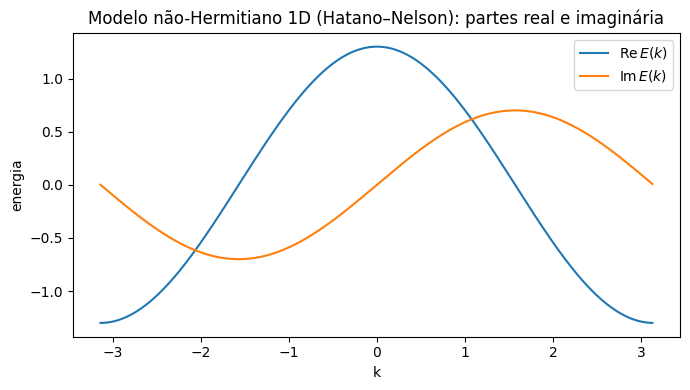

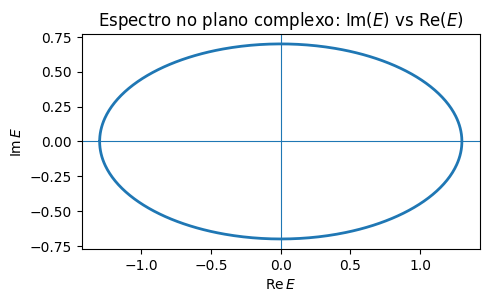

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
a = 1.0
tR = 1.0   # hopping para a direita
tL = 0.3   # hopping para a esquerda (tR != tL -> não-Hermitiano)

Nk = 600
k = np.linspace(-np.pi/a, np.pi/a, Nk, endpoint=False)

# Espectro complexo (PBC): E(k) = tR e^{ika} + tL e^{-ika}
E = tR*np.exp(1j*k*a) + tL*np.exp(-1j*k*a)

ReE = np.real(E)
ImE = np.imag(E)

# 1) Re(E) e Im(E) versus k
plt.figure(figsize=(7,4))
plt.plot(k, ReE, label=r"$\mathrm{Re}\,E(k)$")
plt.plot(k, ImE, label=r"$\mathrm{Im}\,E(k)$")
plt.xlabel("k")
plt.ylabel("energia")
plt.title("Modelo não-Hermitiano 1D (Hatano–Nelson): partes real e imaginária")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Curva no plano complexo: Im(E) vs Re(E)
plt.figure(figsize=(5,5))
plt.plot(ReE, ImE, linewidth=2)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(r"$\mathrm{Re}\,E$")
plt.ylabel(r"$\mathrm{Im}\,E$")
plt.title(r"Espectro no plano complexo: $\mathrm{Im}(E)$ vs $\mathrm{Re}(E)$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

### Interpretando a “banda” complexa: por que aparece uma elipse?

No modelo de Hatano–Nelson com condições periódicas (PBC), a invariância translacional
continua valendo: os autestados ainda podem ser rotulados por um número de onda $k$.
A diferença é que, por ser não-Hermitiano, o autovalor associado a cada $k$ não precisa ser real.
Assim, em vez de uma função real $E(k)$ (uma curva no eixo de energia), obtemos uma função
**complexa** $E(k)$: cada $k$ corresponde a um ponto no plano complexo.

Para este modelo,
$$
E(k)=t_R e^{ika}+t_L e^{-ika}.
$$
Separando partes real e imaginária,
$$
\mathrm{Re}\,E(k)=(t_R+t_L)\cos(ka),\qquad
\mathrm{Im}\,E(k)=(t_R-t_L)\sin(ka).
$$

Eliminando $k$ entre essas duas expressões, obtemos a equação de uma elipse:
$$
\left(\frac{\mathrm{Re}\,E}{t_R+t_L}\right)^2
+
\left(\frac{\mathrm{Im}\,E}{t_R-t_L}\right)^2
=1.
$$

**Interpretação:**
- Em um cristal Hermitiano, “banda” significa o conjunto de energias reais $E(k)$ obtidas ao variar $k$ na 1ª zona de Brillouin.
- Aqui, a definição é análoga: a “banda” é o **conjunto de autovalores** gerados quando $k$ varre a 1ª zona de Brillouin,
  mas agora esse conjunto é uma **curva no plano complexo**.
- A elipse é, portanto, a imagem do círculo unitário $e^{ika}$ (com $k\in[-\pi/a,\pi/a]$) sob a transformação
  $E=t_R z + t_L z^{-1}$, com $z=e^{ika}$.

Do ponto de vista físico, a parte imaginária $\mathrm{Im}\,E(k)$ indica que diferentes modos de Bloch
podem ter **taxas de crescimento/decaimento** diferentes (novamente, dependendo da convenção).
Quando $t_R=t_L$, a elipse colapsa para um segmento no eixo real (voltamos ao caso Hermitiano, com $\mathrm{Im}\,E=0$).
Quando $t_R\neq t_L$, surge uma extensão no eixo imaginário e o espectro “abre” no plano complexo.

> Observação: em modelos não-Hermitianos, as propriedades podem depender de condições de contorno.
> Com PBC, $k$ é um bom número quântico e a “banda complexa” aparece naturalmente como uma curva fechada.


> Quando a gente fala em “banda” aqui, estamos pensando em $k$ como um bom número quântico.
> Com condições periódicas (PBC), $k$ varre a zona de Brillouin e volta ao ponto inicial,
> então a trajetória $E(k)$ no plano complexo tende a formar uma **curva fechada**.

> Curvas **não fechadas** aparecem quando essa parametrização por $k$ deixa de funcionar tão bem:
> por exemplo, em uma cadeia finita com **condições abertas (OBC)**, muitos modelos não-Hermitianos
> deixam de ter autestados do tipo onda plana e o espectro pode virar **arcos** ou um conjunto
> de pontos que não fecha.